# From Equations to Fast, Trustworthy Kernels and Explicit Data

*Stellar Spectroscopy from Scratch — from physical principles to a working code*

Chapter 1 left us with an atmosphere arranged from the outermost layer inward. Later
calculations must integrate through those layers at thousands or millions of
frequencies. That sounds like a problem of speed. It is first a problem of meaning.

A square array can be transposed without changing its shape. A GPU can return a smooth
curve from the wrong axis much faster than a CPU can. A file can keep its familiar name
after one byte changes. Two population arrays can have the same shape and units while
representing different physical quantities. None of these mistakes is repaired by
optimization.

This chapter develops one rule that we will use throughout the book:

> A numerical value is usable only when its physical meaning, units, axes, precision,
> data identity, and validation claim are all explicit.

We will apply that rule to a depth integral, to the distinction between logarithmic
and linear abundances, and to the files used for one reproducible comparison.

A **kernel** is a focused numerical routine that performs one repeated computational
task. Here the task is an integral along depth. Later kernels will compute populations,
opacity, and radiative transfer, but the same trust rule will apply to each.

**What this chapter will build**

We will integrate optical depth by hand and with the exact NumPy, Numba, and Torch
implementations; identify which work can safely run in parallel; measure agreement and
timing with declared policies; translate one abundance example from dex to a linear
mixture; verify the calculation's inputs by checksum; and distinguish two population
arrays that can share a shape without sharing a meaning.

The numerical examples are deliberately small enough to inspect. They are not toy
replacement APIs: the public names, argument order, array layouts, and backend policy
are the ones used by the working implementation.

> **Honest boundary.** Numerical parity is not physical convergence, and a checksum
> proves byte identity rather than physical accuracy. The chapters ahead will
> construct and close the physics those checks cannot supply.

> **Movement I — Make one kernel trustworthy.** Sections 2.1–2.9 follow one depth
> integral from a plausible axis error through an analytic check, compiled CPU
> execution, safe chunk parallelism, device policy, parity, and honest timing. Each
> acceleration step must preserve the contract earned by the previous one.


In [1]:
from pathlib import Path
import sys

repository_root = Path.cwd()
if repository_root.name == "content":
    repository_root = repository_root.parent
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))
source_root = repository_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from book.plot_style import apply_book_plot_style

apply_book_plot_style()


In [2]:
import hashlib
import json
import os
from pathlib import Path
import platform
import subprocess
import sys
import tempfile
import time

import matplotlib.pyplot as plt
import numba
import numpy as np
import torch

from book.chapter02_support import (
    TRANSFER_FIXTURE_PATH,
    TRANSFER_GOLDEN_PATH,
    TRANSFER_OUTPUT_NAMES,
    TRANSFER_TABLE_PATH,
    run_transfer_fixture,
)
from book.plot_style import PAPER_COLORS, add_quiet_grid, single_panel
from payne_zero_atmosphere.radiative_transfer import (
    integrate_on_depth_grid,
    parabolic_coefficients,
)
from payne_zero_atmosphere.transfer_kernels import (
    _integrate_on_depth_grid_compiled,
)
from payne_zero_synthesis.device import (
    ACCUMULATION_DTYPE,
    DEFAULT_DTYPE,
    REFERENCE_DTYPE,
    device,
    resolve_runtime,
)
from payne_zero_synthesis.radiative_transfer import (
    _parabolic_interval_coefficients,
    integrate_optical_depth,
)


## 2.1 The dangerous answer is the one that looks reasonable

We begin with the exact kind of error that a shape check can miss. Let \(W\) be the
number of wavelength samples and \(D\) the number of depth layers. The synthesis
transfer routine expects

$$
\texttt{extinction.shape}=(W,D),
$$

with wavelength along axis 0 and ordered depth along axis 1. We deliberately choose
\(W=D=80\). Transposing the array therefore leaves its shape unchanged.

The depth coordinate is `column_mass`, measured in g cm\(^{-2}\) and increasing
inward. The extinction is positive and measured in cm\(^2\) g\(^{-1}\). Their product
contributes a dimensionless optical depth. We make both axes vary smoothly, then ask
the exact Torch routine to integrate the intended array and its silent transpose.

Before running the cell, predict what a visual inspection can establish. Positivity
and monotonicity may make both curves look credible. Neither property knows which axis
was meant to represent depth.

The opening code uses a **Torch tensor**, a multidimensional numerical array. Its
**dtype** says how each number is represented—here `float64`—and its **device** says
where it lives—here the CPU. `.numpy()` returns a CPU NumPy view for plotting. Section
2.7 will explain what changes when that tensor lives on a GPU.


In [3]:
column_mass = np.geomspace(1.0e-6, 1.0e2, 80)
wavelength_scale = np.geomspace(0.2, 3.0, 80)
depth_scale = 0.3 + 0.7 * (column_mass / column_mass[-1]) ** 0.3
extinction = wavelength_scale[:, None] * depth_scale[None, :]

mass_tensor = torch.as_tensor(column_mass, dtype=torch.float64)
extinction_tensor = torch.as_tensor(extinction, dtype=torch.float64)
correct_tau = integrate_optical_depth(
    mass_tensor,
    extinction_tensor,
    extinction_tensor[:, 0] * mass_tensor[0],
).numpy()

transposed_tensor = extinction_tensor.T.contiguous()
transposed_tau = integrate_optical_depth(
    mass_tensor,
    transposed_tensor,
    transposed_tensor[:, 0] * mass_tensor[0],
).numpy()

selected_wavelength = 36
print("intended shape:", extinction_tensor.shape)
print("transposed shape:", transposed_tensor.shape)
print("both monotone:",
      np.all(np.diff(correct_tau[selected_wavelength]) > 0.0)
      and np.all(np.diff(transposed_tau[selected_wavelength]) > 0.0))


intended shape: torch.Size([80, 80])
transposed shape: torch.Size([80, 80])
both monotone: True


Both inputs report the same shape, and both selected results pass the simple
monotonicity check. The one-panel comparison now shows why neither fact is enough.


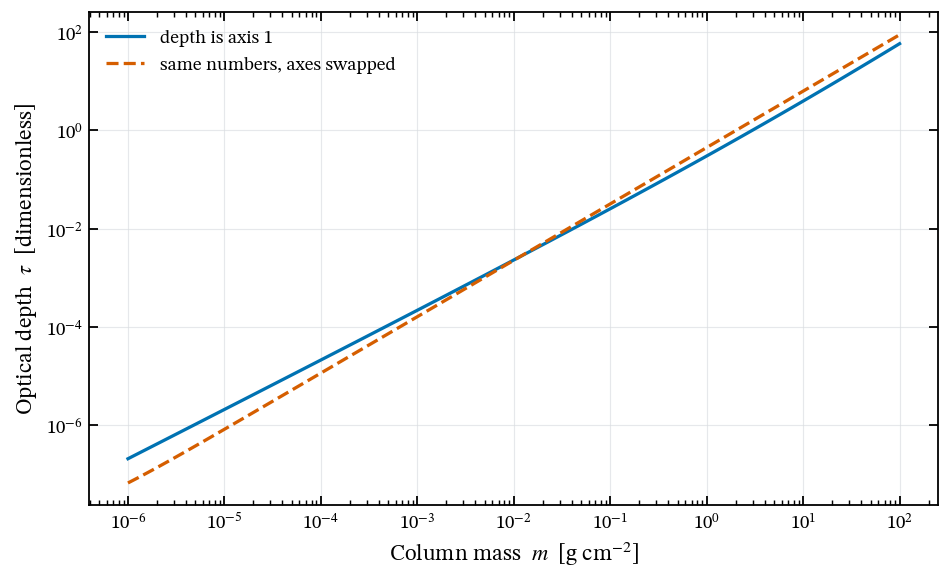

declared layout: 57.5943
silent transpose: 87.4953
bottom-value ratio: 1.51917


In [4]:
figure, axes = single_panel()
axes.loglog(
    column_mass,
    correct_tau[selected_wavelength],
    color=PAPER_COLORS["blue"],
    label="depth is axis 1",
)
axes.loglog(
    column_mass,
    transposed_tau[selected_wavelength],
    "--",
    color=PAPER_COLORS["orange"],
    label="same numbers, axes swapped",
)
axes.set(xlabel=r"Column mass  $m$  [g cm$^{-2}$]",
         ylabel=r"Optical depth  $\tau$  [dimensionless]")
add_quiet_grid(axes)
axes.legend()
plt.show()
plt.close(figure)

print(f"declared layout: {correct_tau[selected_wavelength, -1]:.6g}")
print(f"silent transpose: {transposed_tau[selected_wavelength, -1]:.6g}")
bottom_ratio = (
    transposed_tau[selected_wavelength, -1]
    / correct_tau[selected_wavelength, -1]
)
print(f"bottom-value ratio: {bottom_ratio:.6g}")


Both curves are positive, smooth, and increasing inward. Yet the declared layout ends
at \(\tau=57.5943\), while the silent transpose ends at \(87.4953\)—a factor of
\(1.51917\). The same `(80, 80)` shape and the same 6400 positive numbers have produced
different calculations because axis meaning was lost.

A plot can reveal a disagreement after we know which two cases to compare. It cannot
declare the intended layout. We need a **numerical contract** before we optimize:

$$
\boxed{\text{equation}+\text{units}+\text{axes}+\text{dtype/device}
+\text{data identity}+\text{validation claim}}.
$$

## 2.2 Freeze the physical contract

Chapter 1 introduced optical depth as accumulated interaction strength. On a column
mass coordinate its monochromatic form is

$$
\tau_\nu(m)=\tau_{\nu,0}
+\int_{m_0}^{m}\chi_\nu(m')\,dm'.
$$

Here \(m\) is `column_mass` in g cm\(^{-2}\), \(\chi_\nu\) is mass extinction in
cm\(^2\) g\(^{-1}\), and \(\tau_{\nu,0}\) is a wavelength-specific surface seed.
Because the units cancel, \(\chi_\nu\,dm\) is dimensionless.

The integrator does not derive this seed. It starts the returned array at the supplied
first-layer optical depth. The current synthesis caller uses
`surface_tau = extinction[:, 0] * column_mass[0]`; the hand-audited case below supplies
`0.25` so its normalization is easy to see. Although the exact function docstring calls
the argument a “top half-cell seed,” the executable contract is the caller-supplied
first value—no extra factor of one half is applied inside the routine.

There are two different kinds of dependency:

- Within one wavelength row, the optical depth at layer \(d+1\) contains the result at
  layer \(d\). This is an ordered **recurrence**.
- Different wavelength rows do not need one another. They are independent work.

The distinction will tell us where a parallel loop is safe.


<figure>
  <img src="assets/schematics/textbook/ch02-ordered-depth-v1.png"
       alt="Original textbook schematic of independent wavelength rows, each integrated in ordered depth from a surface seed.">
<figcaption><strong>Dependency schematic.</strong> Each wavelength owns one surface
  seed and one inward recurrence. Rows may be processed independently; positions
  within a row may not be arbitrarily reordered. This is a conceptual dependency
  drawing, not a memory benchmark.</figcaption>
</figure>

The working code keeps two exact interfaces because the atmosphere and synthesis
stages need different layouts:

| exact function | input layout | returned object |
| --- | --- | --- |
| `integrate_on_depth_grid` | `grid (D,)`, `values (D,)`, keyword-only `surface_value` | NumPy `float64 (D,)` |
| `integrate_optical_depth` | `column_mass (D,)`, `extinction (W,D)`, `surface_tau (W,)` | Torch `(W,D)` on the input dtype and device |

We will not hide these differences behind a book-only wrapper. A single column and a
wavelength batch are genuinely different computational objects.

| mistake | can the output look plausible? | what can expose it? |
| --- | --- | --- |
| kg m\(^{-2}\) values supplied as g cm\(^{-2}\) | yes | an analytic or unit-scale check |
| `(D,W)` supplied where `(W,D)` is required | yes, especially if \(D=W\) | a named-axis test |
| depth ordered inward-to-outward | sometimes | a strict monotonic-depth check |
| float32 used under a float64 reference policy | yes | dtype-aware parity and tolerance |

Neither integrator performs dimensional algebra. A later schema can reject several
shape and ordering errors, but it still cannot infer an undeclared unit or discover a
semantic transpose whose shape remains valid.

Formula-specific constant choices also belong to the contract: changing a rounded
parity value to a newer exact literal can change the last bits without changing the
physical dimension. We will name such constants where their formulas first require
them.

## 2.3 One depth column we can audit by hand

Before trusting any implementation, choose a case whose integral fits on one line:

$$
m=[0,1,2,3]\ {\rm g\,cm^{-2}},\qquad
\chi(m)=1+2m\ {\rm cm^2\,g^{-1}},\qquad
\tau_0=0.25.
$$

The analytic answer is

$$
\tau(m)=0.25+\int_0^m(1+2m')\,dm'=0.25+m+m^2,
$$

so we predict `[0.25, 2.25, 6.25, 12.25]`.

The exact routine first represents the extinction on each interval as
\(a+bm+cm^2\). `parabolic_coefficients` builds that representation in four ordered
stages: endpoint secants supply linear boundary estimates; three neighboring samples
supply interior quadratics; the first two near-surface intervals are forced back to
linear form; and adjacent curved estimates are blended with weights set by the
magnitudes of their quadratic terms. The deepest boundary is also copied from its
endpoint secant. These choices suppress fragile curvature where only one-sided
information is available.

Once \(a\), \(b\), and \(c\) are fixed, one interval contributes the exact polynomial
integral

$$
\Delta\tau =
a(m_R-m_L)+\frac{b}{2}(m_R^2-m_L^2)
+\frac{c}{3}(m_R^3-m_L^3).
$$

The public function below performs those interval integrals in outer-to-inner order.
It calls the exact coefficient constructor just described; it is not a simplified
trapezoid.


In [5]:
def integrate_on_depth_grid(
    grid: np.ndarray,
    values: np.ndarray,
    *,
    surface_value: float,
) -> np.ndarray:
    """Integrate on a monotonic depth grid using parabolic intervals."""

    coordinate = np.asarray(grid, dtype=np.float64)
    value = np.asarray(values, dtype=np.float64)
    integral = np.zeros(value.size, dtype=np.float64)
    if value.size == 0:
        return integral
    constant, linear, quadratic = parabolic_coefficients(value, coordinate)
    integral[0] = float(surface_value)
    if value.size == 1:
        return integral
    for index in range(value.size - 1):
        dx = coordinate[index + 1] - coordinate[index]
        segment = constant[index] + 0.5 * linear[index] * (
            coordinate[index + 1] + coordinate[index]
        )
        segment += (quadratic[index] / 3.0) * (
            (coordinate[index + 1] + coordinate[index]) * coordinate[index + 1]
            + coordinate[index] * coordinate[index]
        )
        integral[index + 1] = integral[index] + segment * dx
    return integral


Now execute the predicted case. Printing the analytic and computed arrays side by side
makes normalization errors visible immediately.


In [6]:
hand_column_mass = np.array([0.0, 1.0, 2.0, 3.0], dtype=np.float64)
hand_extinction = 1.0 + 2.0 * hand_column_mass
hand_expected = 0.25 + hand_column_mass + hand_column_mass**2
hand_tau = integrate_on_depth_grid(
    hand_column_mass,
    hand_extinction,
    surface_value=0.25,
)
curved_grid = np.arange(8, dtype=np.float64)
curved_values = 1.0 + curved_grid + curved_grid**2
_, _, curved_quadratic = parabolic_coefficients(
    curved_values, curved_grid
)

print("analytic:", hand_expected)
print("computed:", hand_tau)
print("bit-equal:", np.array_equal(hand_tau, hand_expected))
print("quadratic c across 8-point curved case:", curved_quadratic)


analytic: [ 0.25  2.25  6.25 12.25]
computed: [ 0.25  2.25  6.25 12.25]
bit-equal: True
quadratic c across 8-point curved case: [0. 0. 0. 1. 1. 1. 0. 0.]


The four computed values equal the analytic values exactly in this representable
linear case. The increments grow inward because the interval position and
\(\chi=1+2m\) both grow. This checks recurrence, units, and surface normalization. It
does not yet establish speed or accuracy over a broad dynamic range.

The curved eight-point check prints zero quadratic terms in the deliberately
linearized boundary intervals and \(c=1\) through the well-supported interior, exactly
recovering the curvature of \(1+m+m^2\) there. It makes the boundary policy visible
without placing the 92-line coefficient constructor in one unreadable cell.

Two limits complete the interpretation. If \(\chi\) is constant and the grid spacing
is constant, every layer adds the same optical-depth increment. If there is only one
layer, no interval is traversed and the returned value is simply the supplied surface
seed. Both limits follow directly from the equation and give us two more checks on the
implementation.

## 2.4 Batch wavelengths without erasing depth

A spectrum needs many rows. In the Torch interface their shapes are:

| quantity | shape |
| --- | --- |
| `extinction` | `(W, D)` |
| `column_mass` | `(D,)` |
| interval coefficients | `(W, D)` |
| `interval_width` | `(D-1,)` |
| `interval_tau` | `(W, D-1)` |
| returned `optical_depth` | `(W, D)` |

**Broadcasting** aligns the shared `(D-1,)` interval widths with every wavelength row;
it does not make a conceptual copy of the depth grid. Only `torch.cumsum(..., dim=1)`
is ordered, because axis 1 is depth. The complete exact routine is short enough to
inspect.


In [7]:
def integrate_optical_depth(
    column_mass: torch.Tensor,
    extinction: torch.Tensor,
    surface_tau: torch.Tensor,
) -> torch.Tensor:
    """Cumulative optical depth from parabolic interval integrals.

    ``column_mass`` is the shared depth grid [depth], ``extinction`` is
    [wavelength, depth], and ``surface_tau`` is the top half-cell seed for each
    wavelength.  The only sequential dependence is a prefix sum over depth.
    """
    constant, linear, quadratic = _parabolic_interval_coefficients(
        extinction, column_mass
    )
    n_depth = extinction.shape[1]
    optical_depth = torch.empty_like(extinction)
    optical_depth[:, 0] = surface_tau
    if n_depth == 1:
        return optical_depth

    left_column_mass = column_mass[0 : n_depth - 1]
    right_column_mass = column_mass[1:n_depth]
    interval_width = right_column_mass - left_column_mass
    interval_average = (
        constant[:, 0 : n_depth - 1]
        + 0.5 * linear[:, 0 : n_depth - 1] * (right_column_mass + left_column_mass)
        + (quadratic[:, 0 : n_depth - 1] / 3.0)
        * (
            (right_column_mass + left_column_mass) * right_column_mass
            + left_column_mass * left_column_mass
        )
    )
    interval_tau = interval_average * interval_width
    optical_depth[:, 1:] = surface_tau[:, None] + torch.cumsum(interval_tau, dim=1)
    return optical_depth


We use two rows with different extinction normalizations and different surface seeds.
Copies of the inputs are retained so we can verify that the function does not mutate
them.


In [8]:
batch_column_mass = torch.tensor(
    [0.0, 1.0, 2.0, 3.0], dtype=torch.float64
)
batch_extinction = torch.stack(
    (
        1.0 + 2.0 * batch_column_mass,
        2.0 + 0.5 * batch_column_mass,
    )
)
batch_surface_tau = torch.tensor([0.25, 0.10], dtype=torch.float64)
extinction_before = batch_extinction.clone()
surface_before = batch_surface_tau.clone()

batch_tau = integrate_optical_depth(
    batch_column_mass,
    batch_extinction,
    batch_surface_tau,
)
print("shape:", tuple(batch_tau.shape))
print(batch_tau)
print("row 0 matches hand case:",
      torch.equal(batch_tau[0], torch.as_tensor(hand_expected)))
print("inputs unchanged:",
      torch.equal(batch_extinction, extinction_before)
      and torch.equal(batch_surface_tau, surface_before))
print("dtype and device:", batch_tau.dtype, batch_tau.device)


shape: (2, 4)
tensor([[ 0.2500,  2.2500,  6.2500, 12.2500],
        [ 0.1000,  2.3500,  5.1000,  8.3500]], dtype=torch.float64)
row 0 matches hand case: True
inputs unchanged: True
dtype and device: torch.float64 cpu


Row 0 reproduces the hand-audited result. Changing row 1 has changed no value in row 0:
wavelength rows remain independent while the prefix sum orders depth. The result also
retains the input dtype and device.

An array's **stride** tells us how many bytes memory must advance to move by one index
along each axis. A C-contiguous float64 `(W,D)` array stores adjacent depths eight
bytes apart. Its transpose contains the same values but changes the access pattern.


In [9]:
layout_example = np.empty((80, 80), dtype=np.float64, order="C")
transposed_view = layout_example.T
print("declared (W,D):", layout_example.shape, layout_example.strides,
      layout_example.flags.c_contiguous)
print("transposed view:", transposed_view.shape, transposed_view.strides,
      transposed_view.flags.c_contiguous)


declared (W,D): (80, 80) (640, 8) True
transposed view: (80, 80) (8, 640) False


The depth stride is eight bytes in the declared C-contiguous layout. In the transposed
view it is 640 bytes, and the view is not C-contiguous. These are memory-access facts,
not proof of physical correctness: a contiguous copy of the wrong transpose remains
wrong.

There is no universal axis order in this book. Atmosphere opacity slabs are commonly
`(depth, frequency)`, synthesis transfer tensors are `(wavelength, depth)`, and the
Chapter 1 `planck_bnu` demonstration used `(depth, wavelength)`. We will state the
layout at every boundary rather than silently normalize it.

## 2.5 Compile the recurrence without pretending it is parallel

Python loop overhead matters when an ordered recurrence is called repeatedly. Numba
can compile numerical Python into machine code at run time. Its options answer
different questions:

| exact choice | what it changes | what it does **not** imply |
| --- | --- | --- |
| `njit` | compiles supported numerical Python | independent work has not been identified |
| `cache=True` | stores reusable compilation artifacts | every first call is free |
| `nogil=True` | releases Python's global interpreter lock | threads are not created |
| `parallel=True` | enables Numba's parallel transformation | an ordered recurrence is not independent |
| `prange` | marks iterations that may run in parallel | shared writes are not automatically safe |

The exact module defines `_njit = numba.njit(cache=True, nogil=True)` and compiles a
private `_integrate_on_depth_grid_compiled`. The leading underscore matters: it is an
implementation checkpoint, not a second public integral.

Numerical agreement comes before speed. We first compare the compiled checkpoint with
the public result on a smooth 80-layer column; Section 2.9 will time empty-cache,
cached-process, and warm states separately.


In [10]:
smooth_column_mass = np.geomspace(1.0e-6, 1.0, 80)
smooth_extinction = (
    0.2 + np.sqrt(smooth_column_mass) + 0.1 * smooth_column_mass**2
)
smooth_reference = integrate_on_depth_grid(
    smooth_column_mass, smooth_extinction, surface_value=1.0e-8
)

smooth_compiled = _integrate_on_depth_grid_compiled(
    smooth_column_mass, smooth_extinction, 1.0e-8
)

difference = np.abs(smooth_compiled - smooth_reference)
worst_depth = int(np.argmax(difference))
print(f"max |compiled - public| = {difference[worst_depth]:.3e}")
print(f"worst depth index       = {worst_depth}")
print(f"array-equal             = "
      f"{np.array_equal(smooth_compiled, smooth_reference)}")


max |compiled - public| = 0.000e+00
worst depth index       = 0
array-equal             = True


On this smooth case the public and private compiled arrays are bit-equal: the maximum
difference is zero at every depth. Most importantly, the depth recurrence is still
serial. Compilation has removed interpreter overhead; it has not made layer \(d+1\)
independent of layer \(d\).

## 2.6 Parallelize frequency chunks with private state

The safe independent work lies outside the recurrence. The atmosphere transfer
calculation divides its frequency range into contiguous chunks. Each chunk owns a
private set of nine accumulators, performs ordered work inside its assigned
frequencies, and then contributes those private arrays in a fixed chunk order.

A **thread** is one executing worker. A **race condition** occurs when workers update
shared state without a defined ownership rule. A **reduction** combines private partial
results. Its order matters because floating-point addition is not associative:
\((a+b)+c\) need not have exactly the same last bits as \(a+(b+c)\).

The exact dependency is:

\[
\text{frequency ranges}
\rightarrow \text{private accumulators}
\rightarrow \texttt{prange over chunks}
\rightarrow \text{ordered work inside each chunk}
\rightarrow \text{fixed-order reduction}.
\]

The next bite-size kernel isolates that concurrency pattern from the transfer physics.
Each `prange` iteration writes one unique partial sum, so no two chunks race on the same
slot. The final ordinary `range` loop fixes the reduction order. Because the function
is defined interactively in the notebook, it omits `cache=True`; the production
file-backed kernel uses the cache policy already introduced.


In [11]:
@numba.njit(nogil=True, parallel=True)
def fixed_chunk_sum(values, chunk_count):
    partial = np.zeros(chunk_count, dtype=np.float64)
    width = (values.size + chunk_count - 1) // chunk_count

    for chunk in numba.prange(chunk_count):
        start = chunk * width
        stop = min(start + width, values.size)
        subtotal = 0.0
        for index in range(start, stop):
            subtotal += values[index]
        partial[chunk] = subtotal

    total = 0.0
    for chunk in range(chunk_count):
        total += partial[chunk]
    return partial, total

chunk_values = np.arange(1.0, 17.0)
chunk_partial, chunk_total = fixed_chunk_sum(chunk_values, 4)
print("private chunk sums:", chunk_partial)
print("fixed-order total:", chunk_total)
print("NumPy reference:", np.sum(chunk_values))


private chunk sums: [10. 26. 42. 58.]
fixed-order total: 136.0
NumPy reference: 136.0


The four private sums are `[10, 26, 42, 58]`; their fixed-order reduction gives 136,
equal to the NumPy reference. This is the actual ownership pattern—not the physical
transfer calculation. The production kernel applies the same allocation, one
`prange(chunk_count)` ownership loop, and serial chunk-order reduction to nine
accumulator families.

The small declared fixture below has 4 frequencies, 8 depths, and all inputs required
by the real transfer kernel. Chapter 12 will derive those physical terms. Here the
fixture isolates dependency and accumulation behavior; it is not presented as a
stellar atmosphere.


In [12]:
serial_transfer, parallel_transfer = run_transfer_fixture(chunk_count=2)
repeat_serial, repeat_parallel = run_transfer_fixture(chunk_count=2)

fixed_policy_difference = 0.0
serial_parallel_rows = []
for name in TRANSFER_OUTPUT_NAMES:
    fixed_policy_difference = max(
        fixed_policy_difference,
        float(np.max(np.abs(parallel_transfer[name]
                            - repeat_parallel[name]))),
    )
    absolute = np.abs(serial_transfer[name] - parallel_transfer[name])
    scale = np.maximum(np.abs(serial_transfer[name]), 1.0e-300)
    worst = int(np.argmax(absolute))
    serial_parallel_rows.append(
        (name, float(absolute[worst]),
         float((absolute / scale)[worst]), worst)
    )

worst_row = max(serial_parallel_rows, key=lambda row: row[1])
print(f"fixed-policy repeat max abs: {fixed_policy_difference:.3e}")
print("worst serial/parallel comparison")
print("  accumulator:", worst_row[0])
print(f"  max abs: {worst_row[1]:.3e}")
print(f"  relative at worst index: {worst_row[2]:.3e}")
print("  depth index:", worst_row[3])


/Users/ysting/stellar-spectroscopy-from-scratch-gpu/src/payne_zero_atmosphere/transfer_kernels.py:852: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 1, 'C', False, aligned=True))
  surface_second_moment, _mapped = _transfer_moments_compiled(


fixed-policy repeat max abs: 0.000e+00
worst serial/parallel comparison
  accumulator: temperature_correction_heating_derivative
  max abs: 4.337e-19
  relative at worst index: 1.351e-16
  depth index: 0


The fixed two-chunk policy repeats with zero difference for this executed fixture. The
largest serial-versus-parallel change is \(4.337\times10^{-19}\), in
`temperature_correction_heating_derivative` at depth 0; relative to the serial value
there, it is \(1.351\times10^{-16}\). The regrouping has exposed a last-bit-scale
difference, not a physical discrepancy.

The accumulator arrays are `float64`. Some quantities entering them—including the line
opacity slab and the interpolation operators—are `float32`, so the calculation has
deliberate **float32 precision islands** inside a float64 reduction. Saying simply
“the reduction is float32” would be incorrect.

A one-frequency problem offers almost no chunk-level work. Creating workers and private
buffers can cost more than the arithmetic saved. `prange` is therefore a statement
about independence, not a guarantee of speed.

## 2.7 Put each workload on its actual architecture

A tensor is a multidimensional numerical array carrying a dtype and a device. The
**host** is the CPU and its memory. A CUDA or Apple Metal GPU is a separate device;
moving data to it is an upload, launching work can be asynchronous, and bringing the
final spectrum back is a return transfer.

The computational split follows the dependency we have already uncovered:


<figure>
  <img src="assets/schematics/textbook/ch02-architecture-v1.png"
       alt="Original textbook schematic separating a serial compiled depth recurrence, parallel CPU frequency chunks, and device-resident Torch wavelength batches.">
<figcaption><strong>Architecture schematic.</strong> One ordered depth recurrence can
  be compiled on the CPU; independent atmosphere frequency chunks can use Numba
  workers; broad synthesis tensors can remain resident in Torch on CUDA, MPS, or CPU.
  The physical atmosphere iteration remains a multicore-CPU calculation.</figcaption>
</figure>

The public device policy prefers CUDA, then Apple MPS, then CPU. It uses float64 by
default on CUDA and CPU, but float32 on MPS because Metal does not support float64.
Later line-opacity deposition uses `ACCUMULATION_DTYPE = torch.float32` on every
backend. Those are two distinct precision decisions.

The exact runtime resolver makes the pair explicit.


In [13]:
def resolve_runtime(
    requested_device: torch.device | str | None = None,
    requested_dtype: torch.dtype | None = None,
) -> tuple[torch.device, torch.dtype]:
    """Resolve the public device and dtype defaults as one compatible pair."""

    runtime_device = (
        torch.device(requested_device)
        if requested_device is not None
        else device()
    )
    runtime_dtype = (
        requested_dtype
        if requested_dtype is not None
        else (DEFAULT_DTYPE if runtime_device.type == "mps" else REFERENCE_DTYPE)
    )
    if runtime_device.type == "mps" and runtime_dtype == torch.float64:
        raise ValueError(
            "Apple Metal (MPS) does not support float64; omit dtype or use float32"
        )
    return runtime_device, runtime_dtype


We always test the CPU reference path. If this notebook actually has an available CUDA
or MPS backend, we test that path as well. An unavailable GPU is reported as
unavailable rather than simulated.


In [14]:
tested_devices = ["cpu"]
if torch.cuda.is_available():
    tested_devices.append("cuda")
if torch.backends.mps.is_available():
    tested_devices.append("mps")

print("device | dtype | shape | max_abs_error | tolerance | passed")
for requested in tested_devices:
    runtime_device, runtime_dtype = resolve_runtime(requested, None)
    mass = batch_column_mass.to(
        device=runtime_device, dtype=runtime_dtype
    )
    extinction_on_device = batch_extinction.to(
        device=runtime_device, dtype=runtime_dtype
    )
    seed = batch_surface_tau.to(
        device=runtime_device, dtype=runtime_dtype
    )
    result = integrate_optical_depth(
        mass, extinction_on_device, seed
    ).detach().cpu().to(torch.float64)
    maximum_error = float(torch.max(torch.abs(result - batch_tau)))
    tolerance = 2.0e-5 if runtime_dtype == torch.float32 else 2.0e-12
    print(
        f"{runtime_device.type:6s} | {str(runtime_dtype):13s} | "
        f"{tuple(result.shape)!s:6s} | {maximum_error:13.3e} | "
        f"{tolerance:9.1e} | {maximum_error <= tolerance}"
    )

print("default detected backend:", device())
print("line-deposition accumulation dtype:", ACCUMULATION_DTYPE)


device | dtype | shape | max_abs_error | tolerance | passed
cpu    | torch.float64 | (2, 4) |     0.000e+00 |   2.0e-12 | True


mps    | torch.float32 | (2, 4) |     3.815e-07 |   2.0e-05 | True
default detected backend: mps
line-deposition accumulation dtype: torch.float32


The CPU row establishes the float64 reference comparison. Any additional row names an
accelerator that this notebook actually executed, its real work dtype, measured error,
and policy; a CPU-only rebuild will honestly show no accelerator row. This proves
parity for one optical-depth kernel under the printed policies. It does not prove that
a complete GPU spectrum is correct.


## 2.8 Decide whether two answers are the same

“The curves agree” is not yet a reproducible statement. For a reference array \(r_i\)
and candidate \(c_i\), we will report

$$
\max_i |c_i-r_i|
\quad\text{and}\quad
\max_i\frac{|c_i-r_i|}{\max(|r_i|,\epsilon)},
$$

together with the worst index, dtype, device, monotonicity, and an explicit tolerance.
The small floor \(\epsilon\) prevents division by zero; it does not make errors near
zero unimportant.

Three cases reveal different failures:

1. the exactly representable hand case checks operation and normalization;
2. a smooth positive 80-layer case uses
   `m = geomspace(1e-6, 1, 80)` and
   \(\chi=0.2+\sqrt{m}+0.1m^2\);
3. a positive stress case pairs `m = geomspace(1e-8, 1e2, 80)` with
   `chi = geomspace(1e-12, 1e12, 80)` to expose precision loss.

We compare the public NumPy result with the private compiled CPU checkpoint and with
the exact Torch kernel in float64 and float32. These are chapter result rows, not a new
public result class.


In [15]:
parity_cases = {
    "hand": (
        hand_column_mass,
        hand_extinction,
        0.25,
    ),
    "smooth": (
        smooth_column_mass,
        smooth_extinction,
        1.0e-8,
    ),
    "stress": (
        np.geomspace(1.0e-8, 1.0e2, 80),
        np.geomspace(1.0e-12, 1.0e12, 80),
        1.0e-20,
    ),
}


Each reference uses the same public NumPy recurrence. The tolerances below distinguish
a float64 operation-order comparison from a float32 device-compatible comparison.


In [16]:
print("case | candidate | dtype | max abs | rel@abs | index | monotone | status")
for case_name, (grid, values, seed) in parity_cases.items():
    reference = integrate_on_depth_grid(
        grid, values, surface_value=seed
    )
    candidates = {
        "compiled": _integrate_on_depth_grid_compiled(
            grid, values, seed
        ),
        "torch64": integrate_optical_depth(
            torch.as_tensor(grid, dtype=torch.float64),
            torch.as_tensor(values[None, :], dtype=torch.float64),
            torch.tensor([seed], dtype=torch.float64),
        )[0].numpy(),
        "torch32": integrate_optical_depth(
            torch.as_tensor(grid, dtype=torch.float32),
            torch.as_tensor(values[None, :], dtype=torch.float32),
            torch.tensor([seed], dtype=torch.float32),
        )[0].to(torch.float64).numpy(),
    }
    for candidate_name, candidate in candidates.items():
        dtype_label = "float32" if candidate_name == "torch32" else "float64"
        absolute = np.abs(candidate - reference)
        relative = absolute / np.maximum(np.abs(reference), 1.0e-300)
        worst = int(np.argmax(absolute))
        tolerance = 3.0e-5 if candidate_name == "torch32" else 2.0e-12
        scale = max(float(np.max(np.abs(reference))), 1.0)
        passed = float(np.max(absolute)) <= tolerance * scale
        monotone = bool(np.all(np.diff(candidate) >= 0.0))
        print(
            f"{case_name:6s} | {candidate_name:8s} | "
            f"{dtype_label:7s} | {np.max(absolute):.2e} | "
            f"{relative[worst]:.2e} | {worst:5d} | "
            f"{str(monotone):8s} | {'pass' if passed else 'fail'}"
        )


case | candidate | dtype | max abs | rel@abs | index | monotone | status
hand   | compiled | float64 | 0.00e+00 | 0.00e+00 |     0 | True     | pass
hand   | torch64  | float64 | 0.00e+00 | 0.00e+00 |     0 | True     | pass
hand   | torch32  | float32 | 0.00e+00 | 0.00e+00 |     0 | True     | pass
smooth | compiled | float64 | 0.00e+00 | 0.00e+00 |     0 | True     | pass
smooth | torch64  | float64 | 6.94e-18 | 1.63e-16 |    66 | True     | pass
smooth | torch32  | float32 | 2.98e-08 | 3.31e-08 |    79 | True     | pass
stress | compiled | float64 | 0.00e+00 | 0.00e+00 |     0 | True     | pass
stress | torch64  | float64 | 2.71e-20 | 1.51e-16 |    39 | True     | pass
stress | torch32  | float32 | 1.49e+06 | 4.98e-08 |    79 | True     | pass


All nine rows pass their declared policies. The private compiled result is bit-equal
to the public NumPy result in all three cases. Torch float64 differs by at most
\(6.94\times10^{-18}\) in the smooth case. In the stress case, Torch float32 has a
striking absolute difference of \(1.49\times10^6\), yet its relative difference at the
same index is only about \(5\times10^{-8}\). The table labels that column `rel@abs`:
it is the relative error where absolute error is largest, not a second maximum at a
possibly different depth. This is why absolute and relative error must be read
together, and why exact equality is warranted only when representation and operation
order justify it.

Monotonicity is a useful invariant for positive extinction on an inward-increasing
grid. It still cannot distinguish the two smooth curves in the opening example.
**Parity** means agreement with the declared reference under a declared policy. It
does not mean radiative, hydrostatic, or chemical equilibrium has converged.

## 2.9 Ask what the stopwatch included

A timing statement needs a boundary just as an array needs axes. Import time, first
compilation, cache reload, warm execution, device allocation, host-to-device upload,
synchronization, and device-to-host return are different measurements.

To separate the three Numba states, two fresh subprocesses share one temporary cache.
The first starts from an empty cache and measures compilation plus its first execution.
Its second call is warm in the same process. The second process can reload the newly
written cache but still pays fresh-process import and cache-reconstruction costs.


In [17]:
timing_worker = (
    repository_root / "scripts" / "chapter02_numba_timing_worker.py"
)
worker_command = [
    sys.executable, str(timing_worker), "--depth-count", "320"
]
with tempfile.TemporaryDirectory() as cache_directory:
    worker_environment = os.environ.copy()
    worker_environment["NUMBA_CACHE_DIR"] = cache_directory
    empty_cache = subprocess.run(
        worker_command,
        cwd=repository_root,
        env=worker_environment,
        check=True,
        capture_output=True,
        text=True,
    )
    cached_process = subprocess.run(
        worker_command,
        cwd=repository_root,
        env=worker_environment,
        check=True,
        capture_output=True,
        text=True,
    )
empty_cache_timing = json.loads(empty_cache.stdout)
cached_process_timing = json.loads(cached_process.stdout)
print("Python / NumPy / Numba:",
      platform.python_version(), np.__version__, numba.__version__)
print("machine / logical CPUs / Numba threads:",
      platform.machine(), os.cpu_count(), numba.get_num_threads())
print(f"empty-cache first:  {empty_cache_timing['first_seconds']:.3e} s")
print(f"same-process warm:  {empty_cache_timing['warm_seconds']:.3e} s")
print(f"fresh cached first: {cached_process_timing['first_seconds']:.3e} s")


Python / NumPy / Numba: 3.13.9 2.3.5 0.62.1
machine / logical CPUs / Numba threads: arm64 10 10
empty-cache first:  7.922e-01 s
same-process warm:  6.333e-06 s
fresh cached first: 2.449e-01 s


The three printed times are different boundaries, not three estimates of one number.
The exact ratios are machine- and cache-state dependent, but the empty-cache call
should make the compilation cost visible and the fresh cached process should show that
cache reuse is not identical to an already-warm function.

We now compare warm, same-work calls over several depth counts. Each point is a median
of repeated calls; input construction is outside the timed region. This is a CPU
one-column comparison, not a GPU speed claim and not a timing of the nine-accumulator
transfer kernel.


In [18]:
depth_counts = np.array([20, 80, 320, 1280])
numpy_seconds = []
compiled_seconds = []
repetitions = 9

for depth_count in depth_counts:
    grid = np.geomspace(1.0e-8, 1.0, int(depth_count))
    values = 0.2 + np.sqrt(grid) + 0.1 * grid**2
    _integrate_on_depth_grid_compiled(grid, values, 1.0e-10)
    public_samples = []
    compiled_samples = []
    for _ in range(repetitions):
        start = time.perf_counter()
        integrate_on_depth_grid(grid, values, surface_value=1.0e-10)
        public_samples.append(time.perf_counter() - start)
        start = time.perf_counter()
        _integrate_on_depth_grid_compiled(grid, values, 1.0e-10)
        compiled_samples.append(time.perf_counter() - start)
    numpy_seconds.append(float(np.median(public_samples)))
    compiled_seconds.append(float(np.median(compiled_samples)))

numpy_seconds = np.asarray(numpy_seconds)
compiled_seconds = np.asarray(compiled_seconds)
print("depth counts:", depth_counts)
print("warm NumPy seconds:", numpy_seconds)
print("warm compiled seconds:", compiled_seconds)


depth counts: [  20   80  320 1280]
warm NumPy seconds: [0.00013262 0.00054433 0.00224633 0.01001258]
warm compiled seconds: [3.91702633e-06 5.04200580e-06 3.72079958e-05 4.04579914e-05]


The one-claim plot displays only matched one-column work. A logarithmic time axis keeps
short and long calls readable without exaggerating a tiny absolute difference.


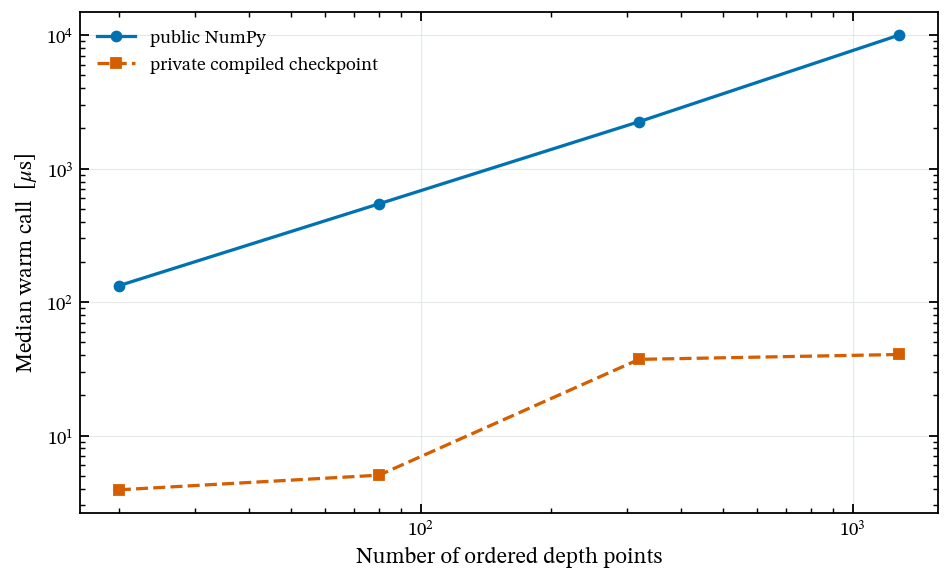

In [19]:
figure, axes = single_panel()
axes.plot(
    depth_counts, 1.0e6 * numpy_seconds, "o-",
    color=PAPER_COLORS["blue"], label="public NumPy"
)
axes.plot(
    depth_counts, 1.0e6 * compiled_seconds, "s--",
    color=PAPER_COLORS["orange"], label="private compiled checkpoint"
)
axes.set(
    xscale="log",
    yscale="log",
    xlabel="Number of ordered depth points",
    ylabel=r"Median warm call  [$\mu$s]",
)
add_quiet_grid(axes)
axes.legend()
plt.show()
plt.close(figure)


No crossover appears in this rendered run: after warm-up, the compiled checkpoint is
faster at every tested size from 20 to 1280 depth points. At 1280 points the public
path is a few milliseconds, while the compiled checkpoint remains below \(0.1\)
millisecond. Those numbers belong to this machine, process, and workload. The public
curve includes coefficient construction and the Python recurrence; the compiled curve
includes the same numerical work after its first call. Input allocation, imports, and
device transfers are excluded.

Device timing would additionally require synchronization: a CUDA or MPS launch may
return before the device finishes. A statement such as “the GPU is \(N\) times faster”
is meaningful only for a matched workload with uploads, synchronization, return
transfer, hardware, dtype, and repeat policy named beside it.

Thread scaling for the full atmosphere transfer is deferred to Chapter 13, where a
sufficiently large fixed workload can amortize chunk scheduling and private buffers.
The four-frequency integration fixture here is intentionally too small to support an
honest scaling curve.

> **Movement II — Preserve meaning around the kernel.** A fast calculation is still
> ambiguous if its abundance convention, input identity, or population meaning is
> unknown. Sections 2.10–2.12 introduce only the distinctions needed before we begin
> the equation of state.

## 2.10 A fast opacity integral still needs a defined mixture

Extinction depends on how many absorbers exist. Before we construct those populations,
we must keep four related ideas separate:

- H is an **element**, defined by one proton.
- Protium and deuterium are **isotopes** of H, with different neutron counts.
- H I and H II are the neutral and singly ionized **stages**.
- H\(_2\) is a **molecule** containing two hydrogen nuclei.

An array slot is only an indexing convention; it does not turn these quantities into
one another.

Astronomers describe elemental number ratios on a logarithmic scale:

$$
A(X)=\log_{10}(n_X/n_H)+12,
$$

$$
[X/H]=\log_{10}(n_X/n_H)_\star-\log_{10}(n_X/n_H)_{\rm ref},
\qquad [X/Fe]=[X/H]-[Fe/H].
$$

A difference measured in **dex** is a base-10 logarithmic difference. Thus
\(A({\rm O})=8.69\) means \(n_{\rm O}/n_H=10^{-3.31}\), and \(+0.30\) dex is nearly a
factor of two.


In [20]:
oxygen_number_ratio = 10.0 ** (8.69 - 12.0)
factor_for_point_three_dex = 10.0**0.30
iron_over_h = -0.50
oxygen_over_iron = +0.20
oxygen_over_h = iron_over_h + oxygen_over_iron

print(f"n_O / n_H for A(O)=8.69: {oxygen_number_ratio:.3e}")
print(f"factor for +0.30 dex: {factor_for_point_three_dex:.3f}")
print(f"[O/H] from [O/Fe]+[Fe/H]: {oxygen_over_h:+.2f}")


n_O / n_H for A(O)=8.69: 4.898e-04
factor for +0.30 dex: 1.995
[O/H] from [O/Fe]+[Fe/H]: -0.30


The first value says that there are about five oxygen nuclei per ten thousand hydrogen
nuclei in this reference mixture. The second shows why a few tenths of a dex is not a
small linear perturbation.

Population equations need **linear number fractions**, not dex values. The next few
lines use H, He, and O only to show the conversion. They are not a substitute for the
complete mixture used later: the denominator contains exactly the species included in
this small example.


In [21]:
species = np.array(["H", "He", "O"])
logarithmic_abundance = np.array([12.00, 10.93, 8.69])
number_ratio_to_h = 10.0 ** (logarithmic_abundance - 12.0)
linear_number_fraction = (
    number_ratio_to_h / number_ratio_to_h.sum()
)

for name, fraction in zip(
    species, linear_number_fraction, strict=True
):
    print(f"{name}: {fraction:.8e}")
print("three-species sum:", linear_number_fraction.sum())


H: 9.21146555e-01
He: 7.84022872e-02
O: 4.51158072e-04
three-species sum: 0.9999999999999999


Exponentiation converts the logarithmic scale into ratios; normalization converts
those ratios into fractions whose sum is one. The distinction matters: adding
\(0.30\) to a dex value is meaningful, but adding \(0.30\) directly to a number
fraction describes a different operation. Chapter 3 will receive a complete linear
elemental mixture and use each element's fraction once in its conservation equation.

## 2.11 Bind a numerical claim to exact bytes

A numerical result also depends on the data that entered it. Three repository roles
are enough for the present calculation:

| role | purpose in a calculation |
| --- | --- |
| static table | fixed coefficients used by the algorithm |
| fixture | a declared input state used to isolate one lesson |
| golden output | a pinned comparison loaded only after the new result exists |

The order matters. If golden output were used as input, agreement would be circular.


<figure>
  <img src="assets/schematics/textbook/ch02-data-roles-v1.png"
       alt="Original textbook schematic separating static tables, computed fixtures, and comparison-only golden data.">
<figcaption><strong>Data-role schematic.</strong> Static tables and declared fixtures
  feed the calculation. Golden output enters only the comparison. Separation prevents
  a reference answer from silently becoming a model input.</figcaption>
</figure>

A **manifest** records a file's role, path, provenance, and checksum. SHA-256 maps a
byte sequence to a compact identity. Matching hashes make accidental byte changes easy
to detect; they do not certify that the coefficients or equations are physically
accurate. We verify only the two inputs used by the transfer calculation above.


In [22]:
data_manifest_path = repository_root / "data" / "MANIFEST.json"
data_manifest = json.loads(data_manifest_path.read_text())
entry_by_name = {
    Path(entry["path"]).name: entry
    for entry in data_manifest["entries"]
}
transfer_inputs = (TRANSFER_FIXTURE_PATH, TRANSFER_TABLE_PATH)
for path in transfer_inputs:
    entry = entry_by_name[path.name]
    observed = hashlib.sha256(path.read_bytes()).hexdigest()
    print(
        entry["role"],
        entry["path"],
        "verified" if observed == entry["sha256"] else "mismatch",
    )


fixture data/fixtures/chapter02_transfer_inputs.npz verified
static data/static/atmosphere_tables/radiative_transfer_tables.npz verified


Both inputs report `verified`, so their paths, roles, and bytes agree with the
manifest. The golden archive is still unopened. We now compare it with the serial and
two-chunk results already computed in Section 2.6.


In [23]:
with np.load(TRANSFER_GOLDEN_PATH, allow_pickle=False) as golden:
    identity_ok = (
        golden["payne_zero_commit"].item()
        == data_manifest["payne_zero_commit"]
        and golden["fixture_sha256"].item()
        == entry_by_name["chapter02_transfer_inputs.npz"]["sha256"]
        and golden["transfer_tables_sha256"].item()
        == entry_by_name["radiative_transfer_tables.npz"]["sha256"]
    )
    serial_matches = [
        np.array_equal(serial_transfer[name], golden[f"serial_{name}"])
        for name in TRANSFER_OUTPUT_NAMES
    ]
    parallel_matches = [
        np.array_equal(
            parallel_transfer[name],
            golden[f"parallel_chunk2_{name}"],
        )
        for name in TRANSFER_OUTPUT_NAMES
    ]
print("golden commit/fixture/table identity:", identity_ok)
print("serial accumulators equal pinned golden:",
      sum(serial_matches), "/", len(serial_matches))
print("two-chunk accumulators equal pinned golden:",
      sum(parallel_matches), "/", len(parallel_matches))


golden commit/fixture/table identity: True
serial accumulators equal pinned golden: 9 / 9
two-chunk accumulators equal pinned golden: 9 / 9


Only after computing the local results did we open the pinned comparison. Its embedded
input identities match the manifest, and every serial and two-chunk accumulator is
array-equal to the corresponding reference. This is a stronger claim than “the two
paths agree with each other”: two implementations can share the same mistake.

The chain of evidence is short enough to remember:

$$
\text{manifest-bound inputs}
\longrightarrow \text{new calculation}
\longrightarrow \text{comparison with pinned output}.
$$

For larger catalogs the same principle applies, even when hashing is performed once
during installation rather than every time a notebook runs.

## 2.12 Same shape is not the same physical quantity

Later calculations carry two population arrays with the same axes:

- `ion_stage_populations` stores actual ion-stage number density \(n\);
- `partition_normalized_populations` stores \(n/U\), divided by the partition function
  \(U\).

A partition function summarizes the internal states available to a species at a given
temperature. Chapter 3 will derive it. Here a two-depth, two-stage array is enough to
expose the representation change without introducing the complete storage layout.


<figure>
  <img src="assets/schematics/textbook/ch02-populations-v1.png"
       alt="Original textbook schematic contrasting equal-shape cubes of actual ion-stage density n and partition-normalized density n divided by U.">
<figcaption><strong>Representation schematic.</strong> Division by the partition
  function preserves shape and density-like units but changes the meaning. The
  normalized value is not a bound-level population.</figcaption>
</figure>


In [24]:
ion_stage_populations = np.array(
    [[1.0e12, 2.0e11], [8.0e11, 4.0e11]]
)
partition_functions = np.array(
    [[4.0, 2.0], [5.0, 2.5]]
)
partition_normalized_populations = (
    ion_stage_populations / partition_functions
)

print("n shape:", ion_stage_populations.shape)
print("n/U shape:", partition_normalized_populations.shape)
print("n at depth 0, stage 0:",
      ion_stage_populations[0, 0])
print("n/U at the same slot:",
      partition_normalized_populations[0, 0])


n shape: (2, 2)
n/U shape: (2, 2)
n at depth 0, stage 0: 1000000000000.0
n/U at the same slot: 250000000000.0


At depth 0 and stage 0, dividing by four changes \(10^{12}\) to
\(2.5\times10^{11}\) while preserving the array shape and density-like units.
Positivity, units, and shape therefore cannot distinguish the two quantities. Actual
ion-stage densities will enter charge conservation. A bound-level LTE calculation
instead begins from \(n/U\), then multiplies by a statistical weight and a Boltzmann
factor. Chapter 3 will derive that sequence before introducing its full array layout.


## 2.13 Chapter summary

We began with two smooth optical-depth curves. Their shared shape, positivity, and
monotonicity could not tell us which axis meant depth. The remedy was not another
plotting convention but an explicit contract.

You can now account for six parts of that contract:

- **Meaning and units:** `column_mass` and mass extinction integrate to dimensionless
  optical depth; logarithmic abundances must be converted before they become linear
  number fractions.
- **Axes:** a wavelength batch is `(W,D)`, and only depth axis 1 participates in the
  ordered prefix sum.
- **Precision and device:** CPU/CUDA reference work defaults to float64, MPS to
  float32, while later line deposition deliberately accumulates in float32.
- **Safe acceleration:** `njit` compiles the depth recurrence; `prange` belongs around
  independent frequency chunks with private state and an explicit reduction.
- **Data identity:** a manifest names a file's role, and SHA-256 binds a claim to exact
  bytes without certifying their physics.
- **Validation claim:** an analytic solution checks the equation, local backend parity
  checks implementations against one another, and a pinned output provides an
  independent regression target. None substitutes for physical convergence.

The final example made the central lesson physical: `ion_stage_populations` and
`partition_normalized_populations` can share shape and units while storing different
quantities. Names, equations, and the code that produces an array must agree.

### Next: count atoms, ions, and electrons

We have named `ion_stage_populations` and
`partition_normalized_populations`, but we have not earned either one. We also need the
free-electron density that couples all ionization stages. In
[Chapter 3: Atoms, Ions, and Electrons](/reader.html?ch=3), we will build these
quantities from conservation laws, partition functions, the Boltzmann distribution,
and Saha ionization equilibrium.
